# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Crea una copia de este notebook en tu google colab**

**Renombra el notebook con el siguiente formato APELLIDO_NOMBRE_PH_TP1.ipynb**

**[Escriba aquí su nombre completo.]**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [1]:
# Instalamos las librerías necesarias
!pip install requests beautifulsoup4 nltk wordcloud scikit-learn --quiet

Utilizamos requests para realizar una petición HTTP GET a la página de La Nación. Luego, con BeautifulSoup, parseamos el HTML y extraemos el texto de todos los párrafos <p> del artículo. El header User-Agent simula un navegador real para evitar bloqueos del servidor.

In [2]:
# ─── WEBSCRAPPING ──────────────────────────────────────────────────────────────
# Fuente: https://www.lanacion.com.ar/deportes/basquetbol/entrevista-exclusiva-a-manu-ginobili-...
# Técnica: requests + BeautifulSoup (parseo de HTML)

import requests
from bs4 import BeautifulSoup

URL = "https://www.lanacion.com.ar/deportes/basquetbol/entrevista-exclusiva-a-manu-ginobili-quiero-estar-tranquilo-quiero-viajar-quiero-aburrirme-nid2122050/"

headers = {"User-Agent": "Mozilla/5.0"}  # evita que el sitio bloquee la petición

response = requests.get(URL, headers=headers)
print(f"Código de respuesta HTTP: {response.status_code}")  # 200 = OK

soup = BeautifulSoup(response.text, "html.parser")

# La Nación guarda el cuerpo del artículo en párrafos <p> dentro del artículo
parrafos = soup.find_all("p")
texto_crudo = " ".join(p.get_text() for p in parrafos)

print(f"\nCaracteres extraídos: {len(texto_crudo)}")
print("\nPrimeros 500 caracteres:\n")
print(texto_crudo[:500])

Código de respuesta HTTP: 200

Caracteres extraídos: 12098

Primeros 500 caracteres:

SAN ANTONIO.–  Aparece su imagen en la pantalla gigante que cuelga del techo del AT&T Center y estalla el estadio. Se anuncia su ingreso al campo de juego y se escucha el estruendo que baja de las tribunas. Sale a hacer su ronda de lanzamientos previos a un encuentro y se desesperan todos, sin nacionalidad en particular, por una foto, un autógrafo o simplemente para que él los salude. Lo esperan en la salida del vestuario dos señoras de la organización con dos fibrones, uno negro y otro plateado


## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

Utilizamos la lista de stop words en español de la librería NLTK (Natural Language Toolkit). Primero tokenizamos el texto con word_tokenize, luego filtramos solo palabras alfabéticas (sin puntuación ni números) y finalmente identificamos cuáles de esas palabras pertenecen al conjunto de stop words del español. Esto nos permite ver qué palabras "vacías" hay que eliminar antes de generar la nube de palabras.

In [3]:
# ─── 2.1 STOP WORDS ────────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Descargamos los recursos necesarios de NLTK
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

# Stop words en español de NLTK
stop_words_es = set(stopwords.words("spanish"))

# Tokenizamos el texto (lo dividimos en palabras)
tokens = word_tokenize(texto_crudo.lower(), language="spanish")

# Filtramos solo palabras (sin puntuación ni números)
palabras = [t for t in tokens if t.isalpha()]

# Identificamos cuáles palabras del texto son stop words
stop_words_presentes = [p for p in palabras if p in stop_words_es]
stop_words_unicas = sorted(set(stop_words_presentes))

print(f"Total de palabras en el texto:            {len(palabras)}")
print(f"Stop words únicas encontradas en el texto: {len(stop_words_unicas)}")
print(f"\nLista de stop words presentes:\n")
print(stop_words_unicas)

Total de palabras en el texto:            2164
Stop words únicas encontradas en el texto: 100

Lista de stop words presentes:

['a', 'al', 'algo', 'algunas', 'ante', 'antes', 'como', 'con', 'cuando', 'de', 'del', 'desde', 'donde', 'el', 'ella', 'ellos', 'en', 'entre', 'era', 'eras', 'es', 'esa', 'esas', 'ese', 'eso', 'esta', 'estaba', 'estamos', 'estar', 'este', 'esto', 'estos', 'estoy', 'está', 'estás', 'fue', 'fuese', 'había', 'hasta', 'hay', 'hubo', 'la', 'las', 'le', 'les', 'lo', 'los', 'me', 'mi', 'mucho', 'muchos', 'muy', 'más', 'mío', 'nada', 'no', 'o', 'otra', 'otras', 'otro', 'otros', 'para', 'pero', 'poco', 'por', 'porque', 'que', 'qué', 'se', 'sea', 'sin', 'sobre', 'somos', 'son', 'soy', 'su', 'sí', 'tanto', 'te', 'tenemos', 'tengas', 'tengo', 'tenía', 'tiene', 'tienen', 'todo', 'todos', 'tu', 'tus', 'tuve', 'tuvieron', 'tuviste', 'un', 'una', 'uno', 'unos', 'y', 'ya', 'yo', 'él']


### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

Preprocesamos el texto pasándolo a minúsculas, tokenizándolo y filtrando: (1) tokens no alfabéticos (puntuación, números, símbolos), (2) stop words en español y (3) palabras de 2 letras o menos. Con el texto resultante generamos la nube de palabras usando WordCloud, donde el tamaño de cada palabra refleja su frecuencia en el texto. Las palabras más grandes serán las que Manu mencionó con más frecuencia en la entrevista.

In [4]:
# ─── 2.2 LIMPIEZA Y NUBE DE PALABRAS ──────────────────────────────────────────
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Limpiamos el texto:
# - Minúsculas
# - Sin puntuación ni caracteres extraños
# - Sin stop words

def limpiar_texto(texto, stop_words):
    tokens = word_tokenize(texto.lower(), language="spanish")
    palabras_limpias = [
        t for t in tokens
        if t.isalpha()              # solo letras (sin números ni puntuación)
        and t not in stop_words     # sin stop words
        and len(t) > 2              # sin palabras muy cortas (ej: "si", "ya")
    ]
    return palabras_limpias

palabras_limpias = limpiar_texto(texto_crudo, stop_words_es)

# Unimos las palabras limpias en un solo string para wordcloud
texto_limpio = " ".join(palabras_limpias)

print(f"Palabras totales antes de limpiar: {len(palabras)}")
print(f"Palabras después de limpiar:       {len(palabras_limpias)}")
print(f"\nMuestra de palabras limpias:\n{palabras_limpias[:30]}")

Palabras totales antes de limpiar: 2164
Palabras después de limpiar:       971

Muestra de palabras limpias:
['san', 'aparece', 'imagen', 'pantalla', 'gigante', 'cuelga', 'techo', 'center', 'estalla', 'estadio', 'anuncia', 'ingreso', 'campo', 'juego', 'escucha', 'estruendo', 'baja', 'tribunas', 'sale', 'hacer', 'ronda', 'lanzamientos', 'previos', 'encuentro', 'desesperan', 'nacionalidad', 'particular', 'foto', 'autógrafo', 'simplemente']


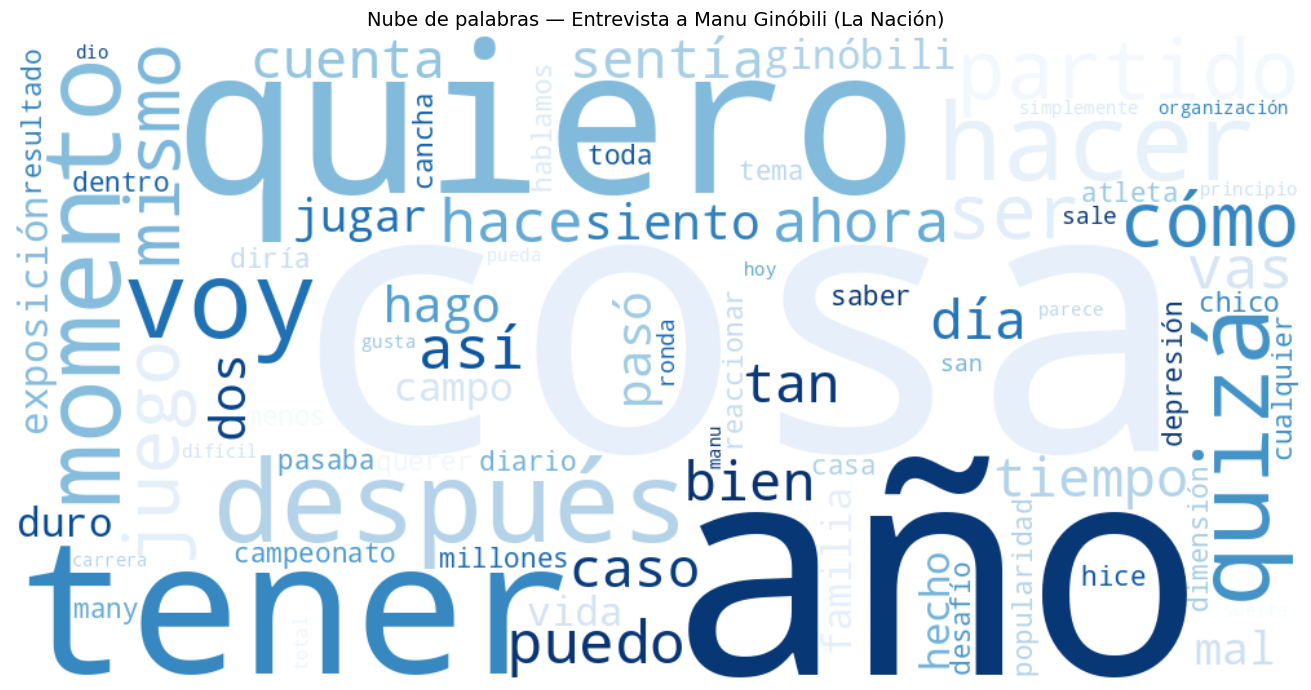

In [5]:
# Generamos la nube de palabras
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="Blues",
    max_words=80,
    collocations=False      # evita repetir pares de palabras
).generate(texto_limpio)

# Mostramos la imagen
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras — Entrevista a Manu Ginóbili (La Nación)", fontsize=14)
plt.tight_layout()
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


Dividimos el texto en oraciones usando sent_tokenize de NLTK, donde cada oración actúa como un "documento" independiente. Luego limpiamos cada oración aplicando el mismo preprocesamiento anterior. Con CountVectorizer de scikit-learn construimos la matriz documento-vocabulario (también llamada Bag of Words): cada fila es una oración y cada columna es una palabra del vocabulario. El valor en cada celda indica cuántas veces aparece esa palabra en esa oración.

In [6]:
# ─── 2.3.1 ORACIONES Y MATRIZ DOCUMENTO-VOCABULARIO ──────────────────────────
import pandas as pd
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import CountVectorizer

# --- Paso 1: dividir el texto en oraciones ---
oraciones_crudas = sent_tokenize(texto_crudo, language="spanish")
print(f"Cantidad de oraciones encontradas: {len(oraciones_crudas)}")
print(f"\nEjemplo (primeras 3 oraciones):")
for i, s in enumerate(oraciones_crudas[:3]):
    print(f"  [{i+1}] {s[:120]}...")

Cantidad de oraciones encontradas: 132

Ejemplo (primeras 3 oraciones):
  [1] SAN ANTONIO.–  Aparece su imagen en la pantalla gigante que cuelga del techo del AT&T Center y estalla el estadio....
  [2] Se anuncia su ingreso al campo de juego y se escucha el estruendo que baja de las tribunas....
  [3] Sale a hacer su ronda de lanzamientos previos a un encuentro y se desesperan todos, sin nacionalidad en particular, por ...


In [7]:
# --- Paso 2: limpiar cada oración (igual que antes, pero por oración) ---
def limpiar_oracion(oracion, stop_words):
    tokens = word_tokenize(oracion.lower(), language="spanish")
    palabras = [
        t for t in tokens
        if t.isalpha()
        and t not in stop_words
        and len(t) > 2
    ]
    return " ".join(palabras)

oraciones_limpias = [limpiar_oracion(o, stop_words_es) for o in oraciones_crudas]

# Filtramos oraciones que quedaron vacías después de la limpieza
oraciones_limpias = [o for o in oraciones_limpias if len(o.strip()) > 0]

print(f"Oraciones después de limpiar: {len(oraciones_limpias)}")
print(f"\nEjemplo (primeras 3 oraciones limpias):")
for i, s in enumerate(oraciones_limpias[:3]):
    print(f"  [{i+1}] {s}")

Oraciones después de limpiar: 131

Ejemplo (primeras 3 oraciones limpias):
  [1] san aparece imagen pantalla gigante cuelga techo center estalla estadio
  [2] anuncia ingreso campo juego escucha estruendo baja tribunas
  [3] sale hacer ronda lanzamientos previos encuentro desesperan nacionalidad particular foto autógrafo simplemente salude


In [8]:
# --- Paso 3: construir la Matriz Documento-Vocabulario (Bag of Words) ---
vectorizer = CountVectorizer()
matriz_doc_vocab = vectorizer.fit_transform(oraciones_limpias)

# Obtenemos el vocabulario
vocabulario = vectorizer.get_feature_names_out()

# Convertimos a DataFrame para visualizarla
df_matriz = pd.DataFrame(
    matriz_doc_vocab.toarray(),
    columns=vocabulario,
    index=[f"Oración {i+1}" for i in range(len(oraciones_limpias))]
)

print(f"\nDimensiones de la matriz: {matriz_doc_vocab.shape}")
print(f"  → {matriz_doc_vocab.shape[0]} documentos (oraciones)")
print(f"  → {matriz_doc_vocab.shape[1]} palabras en el vocabulario")
print(f"\nMuestra de la matriz (primeras 5 oraciones, primeras 10 palabras):")
print(df_matriz.iloc[:5, :10])


Dimensiones de la matriz: (131, 649)
  → 131 documentos (oraciones)
  → 649 palabras en el vocabulario

Muestra de la matriz (primeras 5 oraciones, primeras 10 palabras):
           absoluto  aburrirme  aburro  acatando  acatar  acatarlo  accede  \
Oración 1         0          0       0         0       0         0       0   
Oración 2         0          0       0         0       0         0       0   
Oración 3         0          0       0         0       0         0       0   
Oración 4         0          0       0         0       0         0       0   
Oración 5         0          0       0         0       0         0       0   

           accesorio  aceptaba  acerca  
Oración 1          0         0       0  
Oración 2          0         0       0  
Oración 3          0         0       0  
Oración 4          0         0       0  
Oración 5          0         0       0  



#### 2.3.2 Determina la longitud de tu vocabulario.

El vocabulario está compuesto por las 649 palabras únicas que aparecen en el texto después del preprocesamiento. Este número es la cantidad de columnas de la matriz documento-vocabulario. Para dar más contexto, también mostramos las palabras más frecuentes, que nos dan una idea de los temas centrales de la entrevista. Se espera que términos como equipo, partido, familia o años lideren el ranking, reflejo del contenido de la entrevista con Ginóbili.

In [9]:
# ─── 2.3.2 LONGITUD DEL VOCABULARIO ──────────────────────────────────────────
from collections import Counter

longitud_vocabulario = len(vocabulario)
print(f"Longitud del vocabulario: {longitud_vocabulario} palabras únicas")

# Bonus: las 15 palabras más frecuentes del vocabulario
conteo = Counter(palabras_limpias)
print(f"\nTop 15 palabras más frecuentes:")
for palabra, frecuencia in conteo.most_common(15):
    print(f"  {palabra:<20} → {frecuencia} veces")

Longitud del vocabulario: 649 palabras únicas

Top 15 palabras más frecuentes:
  años                 → 11 veces
  quiero               → 11 veces
  tener                → 9 veces
  cosas                → 9 veces
  después              → 9 veces
  hacer                → 8 veces
  voy                  → 8 veces
  quizá                → 7 veces
  juego                → 6 veces
  cómo                 → 6 veces
  ser                  → 6 veces
  mismo                → 6 veces
  puedo                → 6 veces
  así                  → 6 veces
  momento              → 6 veces



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

Aplicamos TF-IDF (Term Frequency - Inverse Document Frequency) con TfidfVectorizer de scikit-learn sobre las mismas oraciones limpias. La matriz resultante tiene las mismas dimensiones que la Bag of Words (131 × 649), pero los valores ya no son conteos enteros sino pesos decimales entre 0 y 1. Una palabra tiene alto peso TF-IDF en una oración si aparece frecuentemente en ella pero poco en el resto del texto, lo que indica que es representativa de esa oración en particular. A diferencia del simple conteo, TF-IDF penaliza palabras que aparecen en casi todas las oraciones, haciéndola una representación más informativa del contenido.

In [10]:
# ─── 2.3.3 TF-IDF ─────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer

# Aplicamos TF-IDF sobre las mismas oraciones limpias
tfidf_vectorizer = TfidfVectorizer()
matriz_tfidf = tfidf_vectorizer.fit_transform(oraciones_limpias)

# Convertimos a DataFrame para visualizar
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    columns=vocab_tfidf,
    index=[f"Oración {i+1}" for i in range(len(oraciones_limpias))]
)

print(f"Dimensiones de la matriz TF-IDF: {matriz_tfidf.shape}")
print(f"  → {matriz_tfidf.shape[0]} documentos (oraciones)")
print(f"  → {matriz_tfidf.shape[1]} palabras en el vocabulario")
print(f"\nMuestra (primeras 5 oraciones, primeras 8 palabras):")
print(df_tfidf.iloc[:5, :8].round(4))

Dimensiones de la matriz TF-IDF: (131, 649)
  → 131 documentos (oraciones)
  → 649 palabras en el vocabulario

Muestra (primeras 5 oraciones, primeras 8 palabras):
           absoluto  aburrirme  aburro  acatando  acatar  acatarlo  accede  \
Oración 1       0.0        0.0     0.0       0.0     0.0       0.0     0.0   
Oración 2       0.0        0.0     0.0       0.0     0.0       0.0     0.0   
Oración 3       0.0        0.0     0.0       0.0     0.0       0.0     0.0   
Oración 4       0.0        0.0     0.0       0.0     0.0       0.0     0.0   
Oración 5       0.0        0.0     0.0       0.0     0.0       0.0     0.0   

           accesorio  
Oración 1        0.0  
Oración 2        0.0  
Oración 3        0.0  
Oración 4        0.0  
Oración 5        0.0  


In [11]:
# Palabras con mayor peso TF-IDF promedio (las más "distintivas" del texto)
tfidf_promedio = df_tfidf.mean(axis=0).sort_values(ascending=False)

print("\nTop 15 palabras con mayor peso TF-IDF promedio:")
for palabra, score in tfidf_promedio.head(15).items():
    print(f"  {palabra:<20} → {score:.4f}")


Top 15 palabras con mayor peso TF-IDF promedio:
  quiero               → 0.0228
  años                 → 0.0206
  cosas                → 0.0193
  voy                  → 0.0191
  hacer                → 0.0184
  hace                 → 0.0179
  tener                → 0.0175
  quizá                → 0.0173
  después              → 0.0173
  pasó                 → 0.0150
  momento              → 0.0139
  cuenta               → 0.0139
  caso                 → 0.0138
  tan                  → 0.0133
  cosa                 → 0.0131


Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.


# Anexo, código de ejemplo del uso de wordcloud

Instalar e importar la librería

In [ ]:
# instalar wordcloud
!pip install wordcloud


In [ ]:

# Importar librerías
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [ ]:

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Crear un objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)


Mostramos la imagen generada

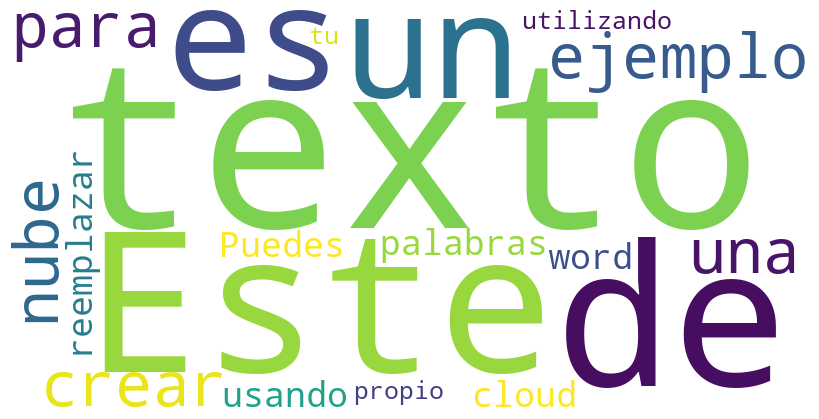

In [ ]:

# mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Modificamos el ejemplo anterior agregando palabras en español que no queremos que considere para crear la nube de palabras. Estas son las stop_words



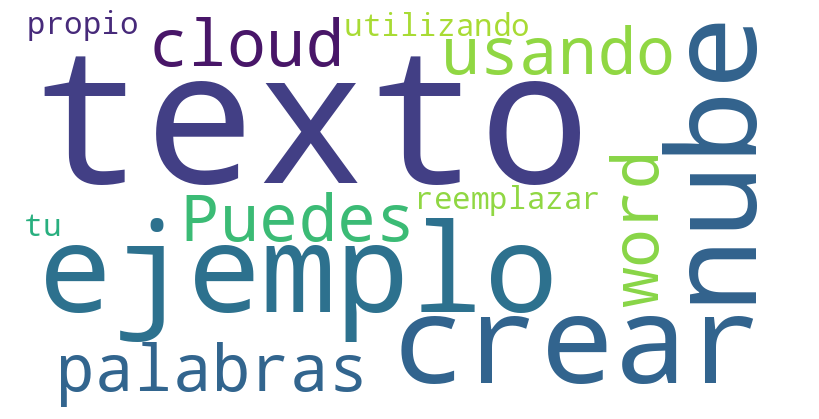

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Definir stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()
